<a href="https://colab.research.google.com/github/Valeriaya512/R/blob/main/%E9%9B%86%E7%BE%A4%E5%88%86%E6%9E%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##　集群分析
1. 階層式集群分析 - 由下往上、由大到小的分群過程
2. K-means集群：決定K個群，隨機挑選中心，計算WGSS直到最小

| 特性       | 階層式集群           | K-means     |
| -------- | --------------- | ----------- |
| 原理       | 逐步合併最相似的群       | 迭代優化群中心     |
| 結果       | 樹狀圖（dendrogram） | K 個群        |
| 速度       | 慢 O(n³)         | 快 O(n)      |
| 適用數據量    | < 1000          | > 1000      |
| 需要指定 K 嗎 | 不需要（事後決定）       | 需要（事前指定）    |
| 可解釋性     | 高（可看合併過程）       | 中（只看最終結果）   |
| 對異常值敏感   | 是               | 是           |
| 假設群形狀    | 無               | 球形          |
| 重現性      | 固定（确定性）         | 可能不同（依賴初始值） |

一、階層式集群（Hierarchical Clustering）\
原理：
1. 由下而上（Agglomerative）：

    * 每個點先自成一群

    *  逐步合併最相似的兩群

    * 直到所有點併成一群

2. 由上而下（Divisive）：

    * 所有點先在同一群

    * 逐步分裂成小群

    * 直到每個點自成一群

##### 應用場景
✅ 適合：

* 數據量小（< 1000 筆）

* 需要可解釋性（想看合併過程）

* 不確定要分幾群

* 生物資訊（基因樹、物種演化）

* 文件分類（文件相似度）

❌ 不適合：

* 大數據集（速度慢）

* 需要快速迭代

* 數據有很多異常值

限制
* 計算複雜度高：O(n³)，數據量大時很慢

* 對異常值敏感：一個異常值可能影響整個樹狀結構

* 一旦合併無法撤回：錯誤的合併會影響後續

* 需要記憶體儲存距離矩陣：O(n²)

In [26]:
install.packages(c("tidyverse", "plotly", "cluster", "factoextra", "gplots"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘litedown’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘markdown’, ‘png’, ‘jpeg’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘gridtext’, ‘showtextdb’, ‘corrplot’, ‘lazyeval’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘ggtext’, ‘irlba’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘showtext’, ‘sysfonts’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘bitops’, ‘crosstalk’, ‘dendextend’, ‘FactoMineR’, ‘ggpubr’, ‘ggrepel’, ‘gtools’, ‘caTools’




Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/library/principal-component-methods



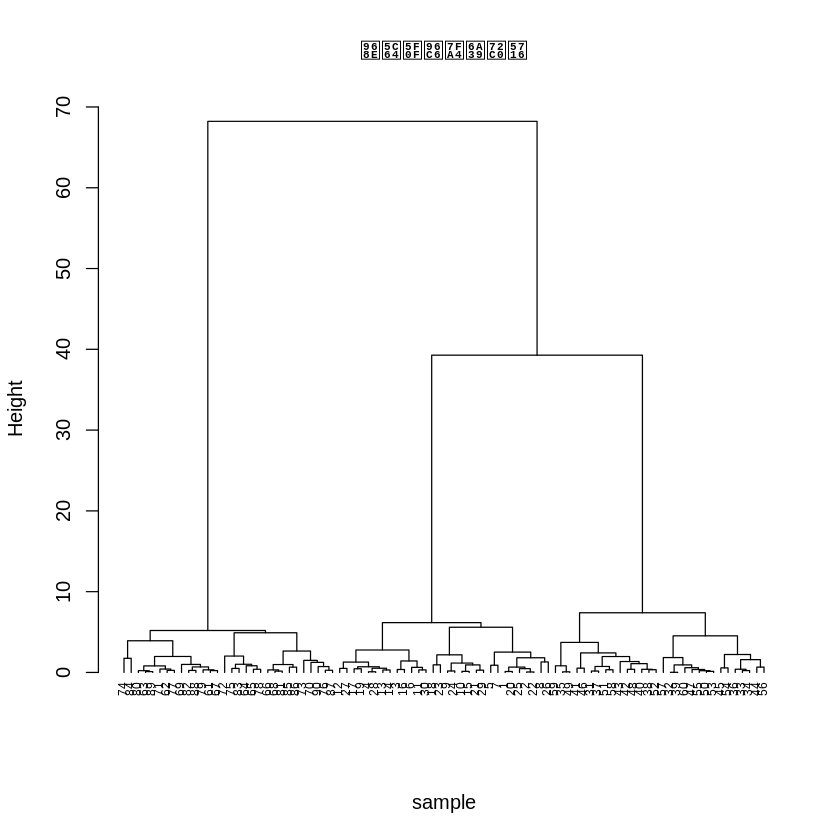

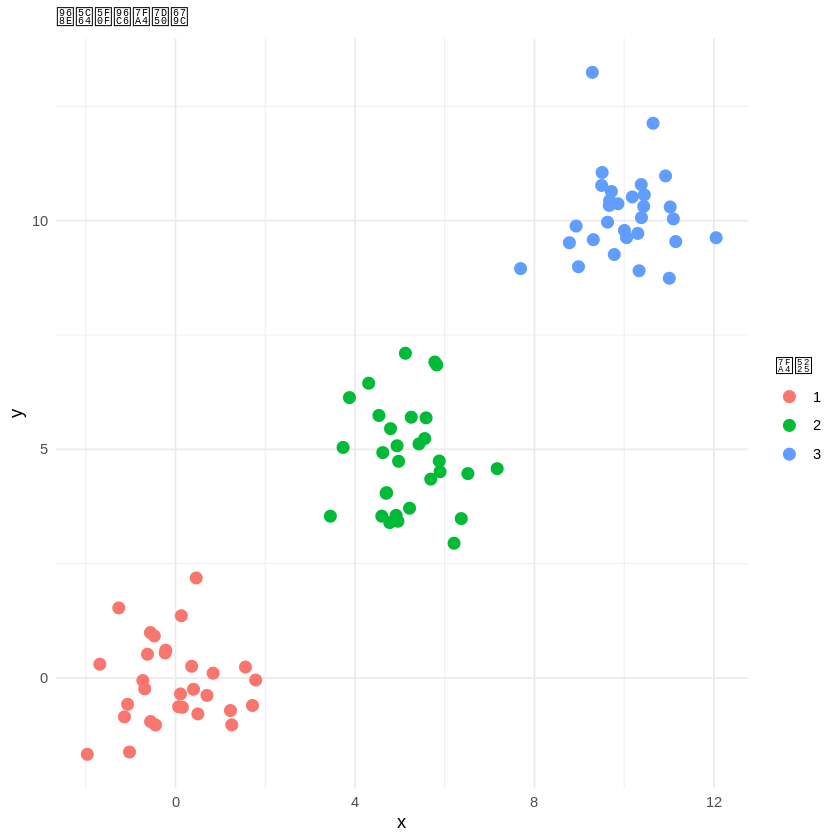

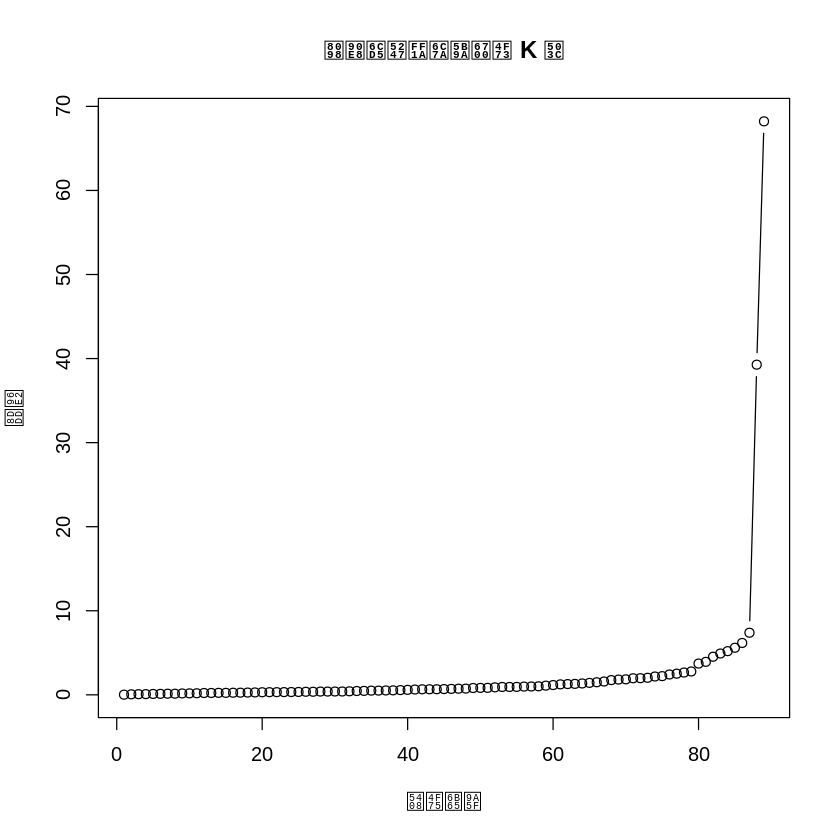

In [27]:
library(tidyverse)

# 檢查並安裝缺失的套件

library(cluster)
library(factoextra)

set.seed(123)

# 建立數據
data <- data.frame(
  x = c(rnorm(30, 0, 1), rnorm(30, 5, 1), rnorm(30, 10, 1)),
  y = c(rnorm(30, 0, 1), rnorm(30, 5, 1), rnorm(30, 10, 1))
)

# 1. 計算距離矩陣
dist_matrix <- dist(data, method = "euclidean")

# 2. 執行階層式集群
hc <- hclust(dist_matrix, method = "ward.D2")

# 3. 畫樹狀圖
plot(hc,
     main = "階層式集群樹狀圖",
     xlab = "sample",
     sub = "",
     hang = -1,
     cex = 0.6)

# 4. 切割成 K 群
clusters <- cutree(hc, k = 3)
data$cluster <- clusters

# 5. 視覺化
ggplot(data, aes(x = x, y = y, color = factor(cluster))) +
  geom_point(size = 3) +
  labs(title = "階層式集群結果",
       color = "群別") +
  theme_minimal()

# 6. 決定最佳 K 值
plot(hc$height, type = "b",
     xlab = "合併步驟",
     ylab = "距離",
     main = "肘部法則：決定最佳 K 值")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

---------------------
gplots 3.3.0 loaded:
  * Use citation('gplots') for citation info.
  * Homepage: https://talgalili.github.io/gplots/
  * Report issues: https://github.com/talgalili/gplots/issues
  * Ask questions: https://stackoverflow.com/questions/tagged/gplots
  * Suppress this message with: suppressPackageStartupMessages(library(gplots))
---------------------



Attaching package: ‘gplots’


The following object is masked from ‘package:stats’:

    lowess




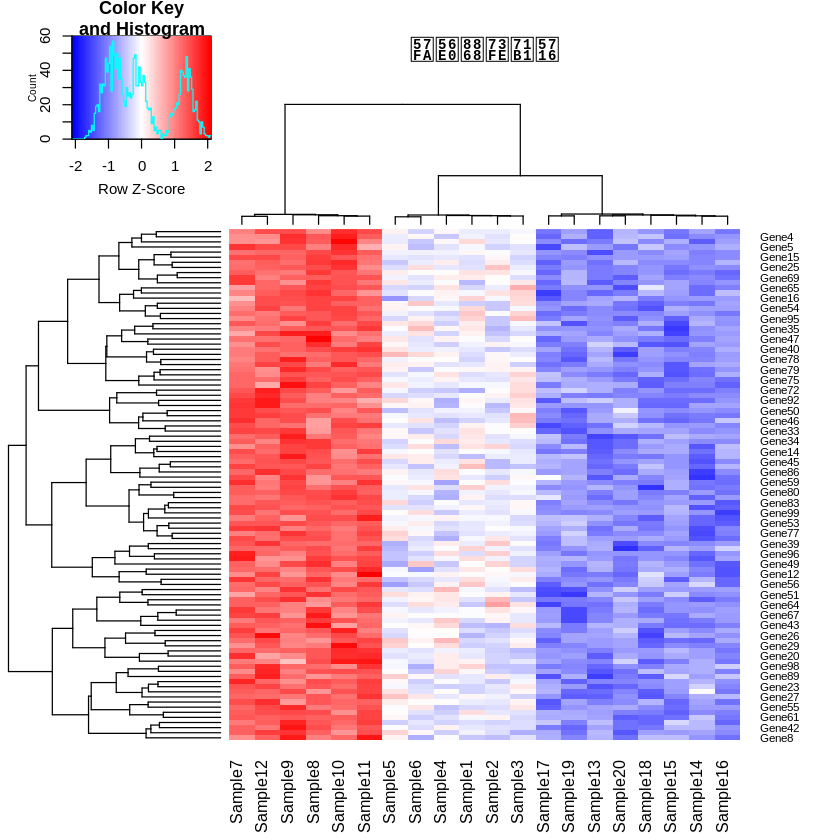

In [ ]:
library(tidyverse)
library(gplots)

set.seed(123)

# 基因表現數據（100 個基因 × 20 個樣本）
gene_data <- matrix(
  c(rnorm(600, 0, 1),   # 群 1
    rnorm(600, 5, 1),   # 群 2
    rnorm(800, -3, 1)), # 群 3
  nrow = 100, ncol = 20
)

rownames(gene_data) <- paste0("Gene", 1:100)
colnames(gene_data) <- paste0("Sample", 1:20)

# 階層式集群
hc_genes <- hclust(dist(gene_data), method = "ward.D2")
hc_samples <- hclust(dist(t(gene_data)), method = "ward.D2")

# 畫熱圖
heatmap.2(
  gene_data,
  Rowv = as.dendrogram(hc_genes),
  Colv = as.dendrogram(hc_samples),
  col = colorRampPalette(c("blue", "white", "red"))(100),
  scale = "row",
  trace = "none",
  main = "基因表現熱圖"
)

二、K-means 集群\
原理：
* 隨機選擇 K 個初始中心點

* 將每個點分到最近的中心點

* 重新計算每個群的中心點

* 重複步驟 2-3 直到收斂

應用場景\
✅ 適合：

* 大數據集（> 1000 筆）

* 需要快速計算

* 已知大概要分幾群

* 市場區隔（客戶分群）

* 圖像壓縮（顏色量化）

* 推薦系統（用戶分群）

❌ 不適合：

* 群不是球形（如環狀、螺旋狀）

* 群大小差異很大

* 有很多異常值

* 需要可解釋的合併過程

限制：
* 需要事先指定 K：不知道要分幾群時很麻煩

* 假設群是球形：對非球形群效果差

* 對初始值敏感：不同初始值可能得到不同結果

* 對異常值敏感：異常值會拉偏群中心

* 只能處理數值資料：不能處理類別變數

In [ ]:
library(tidyverse)

set.seed(123)

# 客戶數據
customers <- data.frame(
  age = c(rnorm(100, 25, 5), rnorm(100, 45, 5), rnorm(100, 65, 5)),
  income = c(rnorm(100, 30000, 5000),
             rnorm(100, 60000, 10000),
             rnorm(100, 40000, 8000)),
  spending = c(rnorm(100, 5000, 1000),
               rnorm(100, 15000, 3000),
               rnorm(100, 8000, 2000))
)

# K-means 分群
kmeans_result <- kmeans(customers, centers = 3, nstart = 25)
customers$cluster <- kmeans_result$cluster

# 分析每群特徵
customers %>%
  group_by(cluster) %>%
  summarise(
    平均年齡 = mean(age),
    平均收入 = mean(income),
    平均消費 = mean(spending),
    人數 = n()
  )

# 結果解讀：
# Cluster 1: 年輕、低收入、低消費 → 學生族群
# Cluster 2: 中年、高收入、高消費 → 高價值客戶
# Cluster 3: 老年、中收入、中消費 → 退休族群

cluster,平均年齡,平均收入,平均消費,人數
<int>,<dbl>,<dbl>,<dbl>,<int>
1,44.43916,64403.62,15049.190,83
2,58.71263,43843.47,9466.171,89
3,36.23272,29736.96,5812.059,128


Loading required package: factoextra

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘factoextra’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘shape’, ‘future.apply’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘RcppTOML’, ‘here’, ‘BH’, ‘sitmo’, ‘pixmap’, ‘sp’, ‘sparsevctrs’, ‘globals’, ‘clock’, ‘gower’, ‘ipred’, ‘reticulate’, ‘RSpectra’, ‘FNN’, ‘RcppAnnoy’, ‘dqrng’, ‘RcppProgress’, ‘modelenv’, ‘ggpubr’, ‘ade4’, ‘ca’, ‘hardhat’, ‘igraph’, ‘mclust’, ‘parsnip’, ‘recipes’, ‘Rtsne’, ‘umap’, ‘uwot’, ‘workflows’


Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/library/principal-component-methods



[1] "=== 群中心 ==="
           x           y
1 5.14640827  4.99147946
2 9.74609957 10.24945076
3 0.03440355  0.03880684


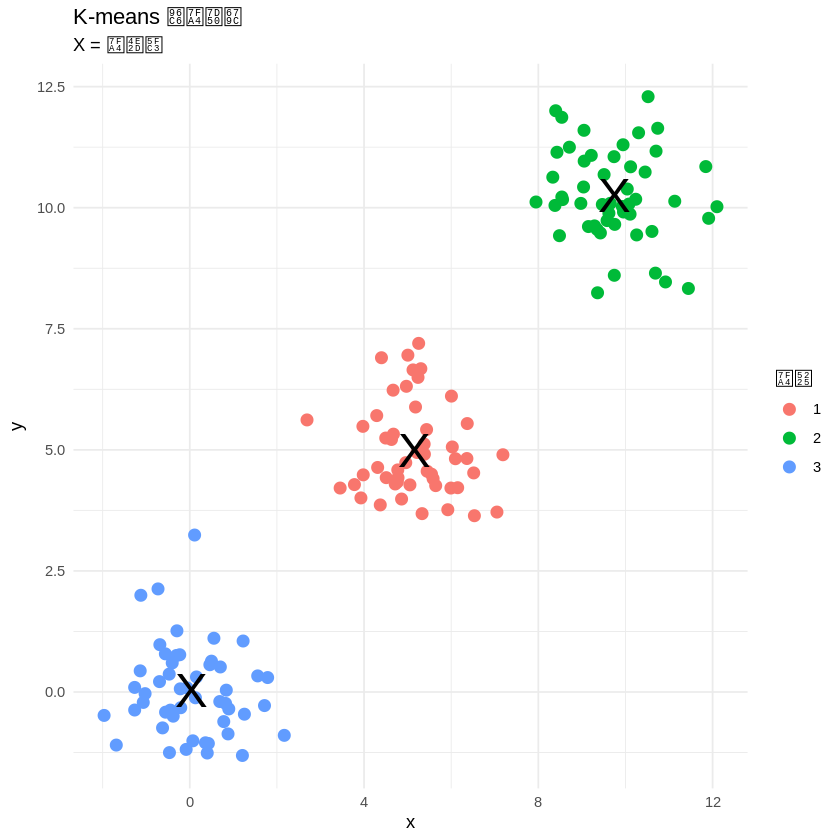

  cluster size ave.sil.width
1       1   50          0.75
2       2   50          0.76
3       3   50          0.78


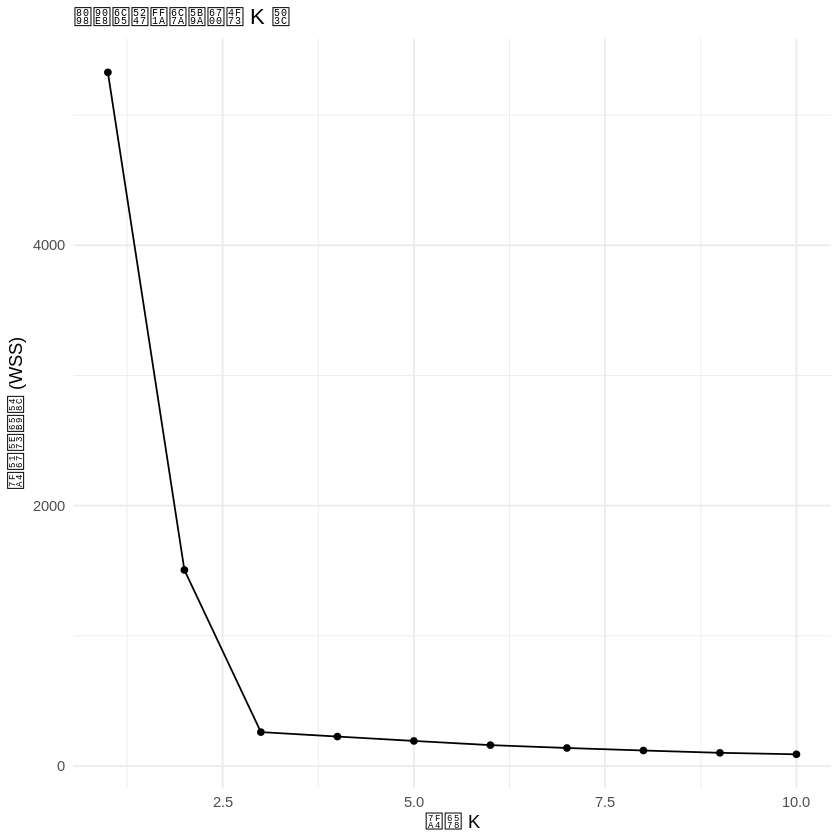

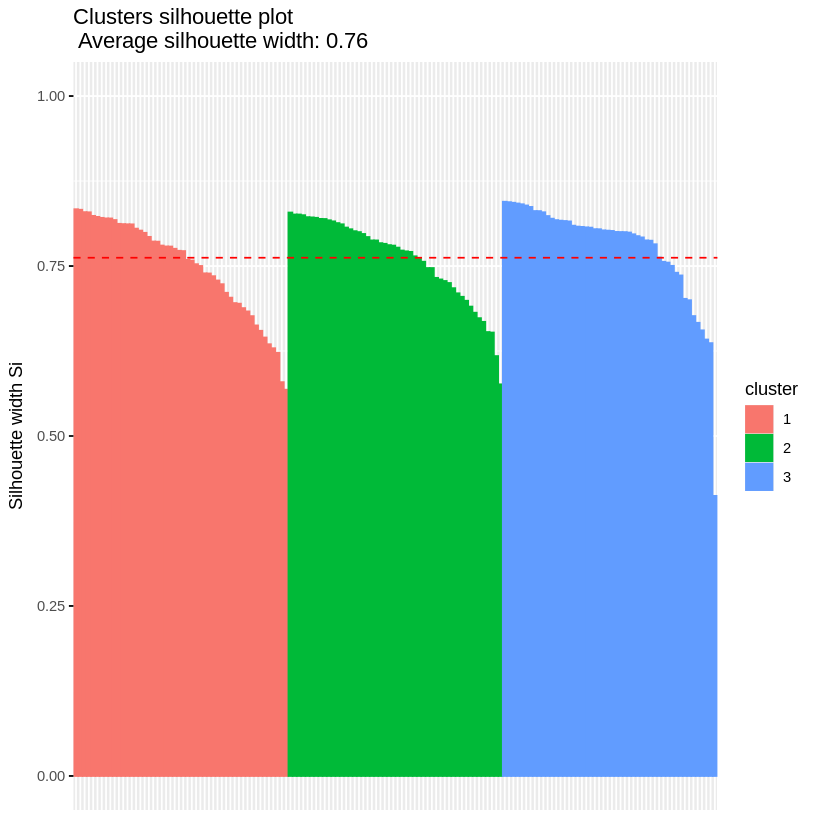

In [ ]:
library(tidyverse)

# 檢查並嘗試安裝缺失的套件
if (!require("factoextra")) install.packages("factoextra", dependencies = TRUE)
if (!require("cluster")) install.packages("cluster", dependencies = TRUE)

library(factoextra)
library(cluster)

set.seed(123)

# 建立數據
data <- data.frame(
  x = c(rnorm(50, 0, 1), rnorm(50, 5, 1), rnorm(50, 10, 1)),
  y = c(rnorm(50, 0, 1), rnorm(50, 5, 1), rnorm(50, 10, 1))
)

# 1. 執行 K-means
kmeans_result <- kmeans(data, centers = 3, nstart = 25)

# 2. 查看結果
print("=== 群中心 ===")
print(kmeans_result$centers)

# 3. 視覺化
data$cluster <- kmeans_result$cluster

ggplot(data, aes(x = x, y = y, color = factor(cluster))) +
  geom_point(size = 3) +
  geom_point(data = as.data.frame(kmeans_result$centers),
             aes(x = x, y = y),
             color = "black", size = 10, shape = "X") +
  labs(title = "K-means 集群結果",
       subtitle = "X = 群中心",
       color = "群別") +
  theme_minimal()

# 4. 決定最佳 K 值（肘部法則）
wss <- sapply(1:10, function(k) {
  kmeans(data, centers = k, nstart = 25)$tot.withinss
})

elbow_data <- tibble(k = 1:10, wss = wss)

ggplot(elbow_data, aes(x = k, y = wss)) +
  geom_line() +
  geom_point() +
  labs(title = "肘部法則：決定最佳 K 值",
       x = "群數 K",
       y = "群內平方和 (WSS)") +
  theme_minimal()

# 5. 輪廓係數
sil <- silhouette(kmeans_result$cluster, dist(data))
fviz_silhouette(sil)

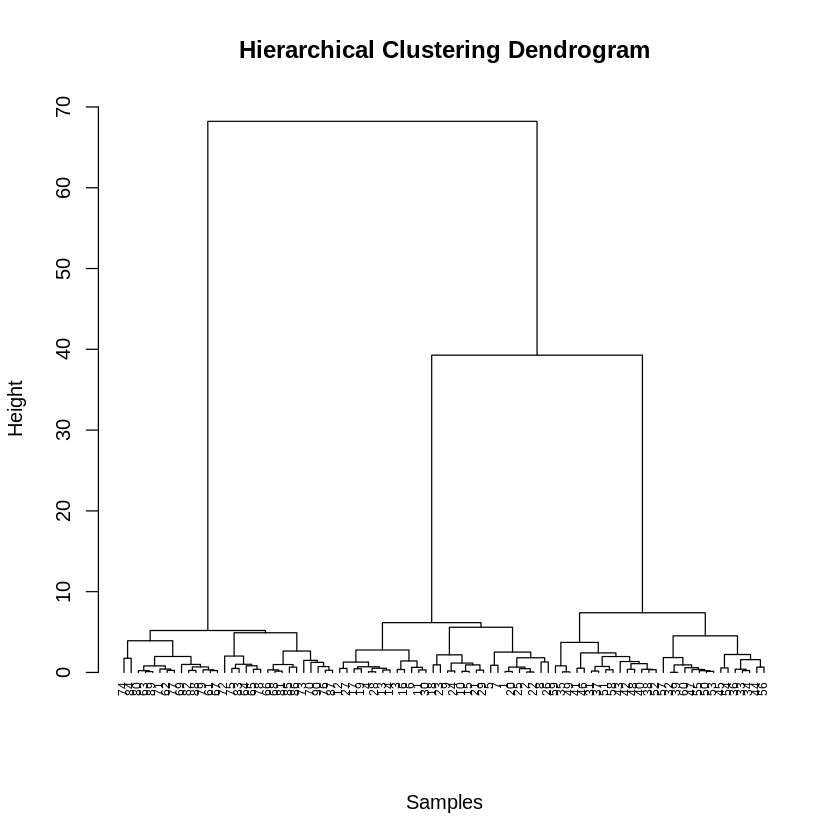

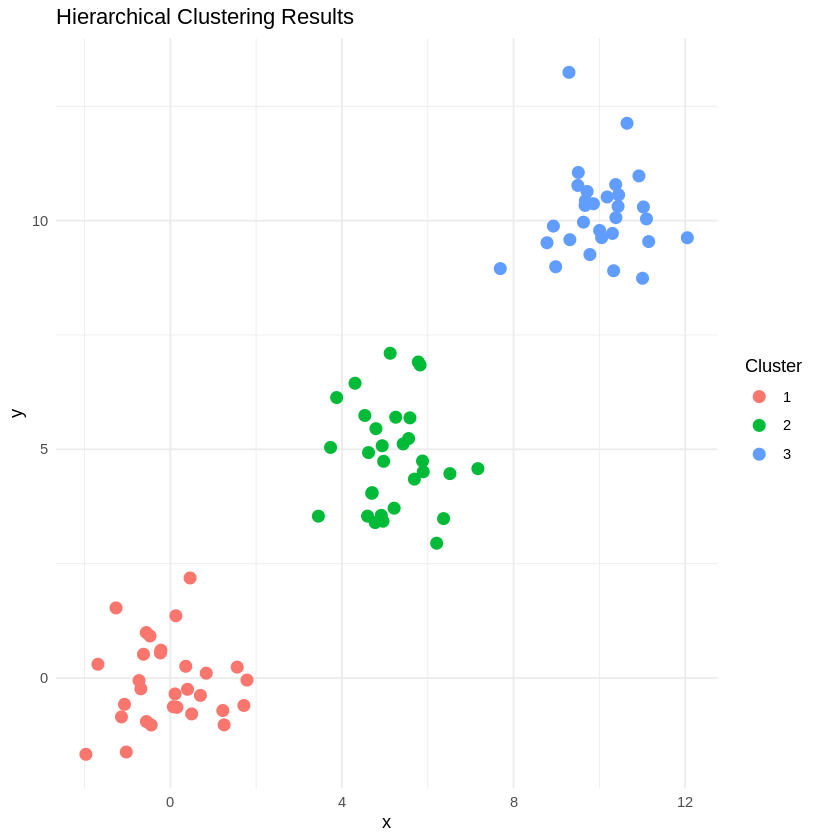

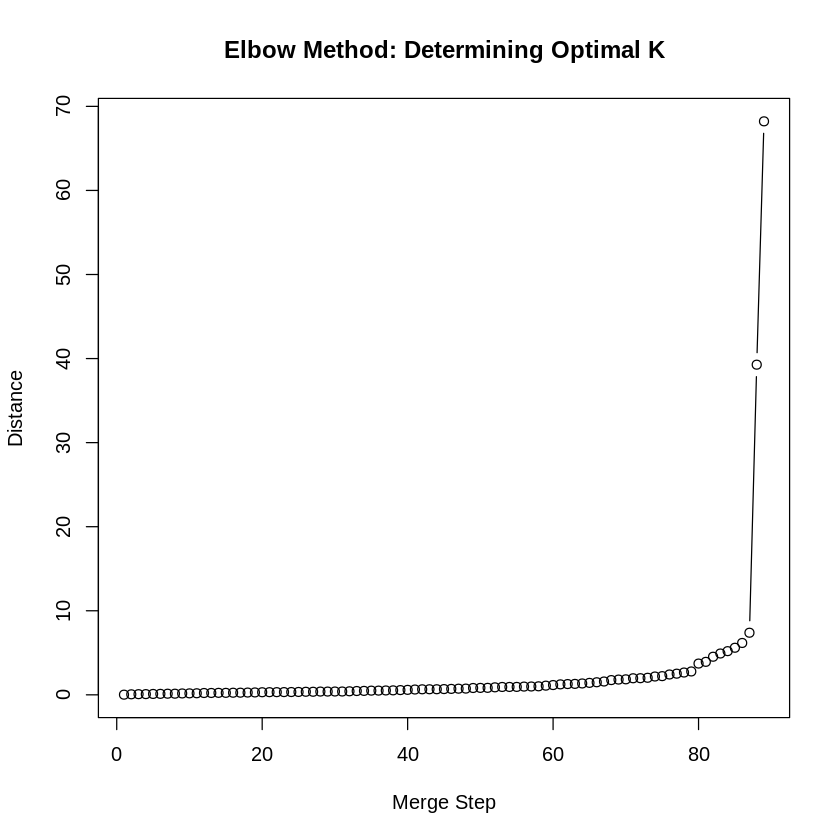

In [ ]:
library(tidyverse)

# Check and install missing packages
if (!require("cluster")) install.packages("cluster")
if (!require("factoextra")) install.packages("factoextra")

library(cluster)
library(factoextra)

set.seed(123)

# Create data
data <- data.frame(
  x = c(rnorm(30, 0, 1), rnorm(30, 5, 1), rnorm(30, 10, 1)),
  y = c(rnorm(30, 0, 1), rnorm(30, 5, 1), rnorm(30, 10, 1))
)

# 1. Calculate distance matrix
dist_matrix <- dist(data, method = "euclidean")

# 2. Perform Hierarchical Clustering
hc <- hclust(dist_matrix, method = "ward.D2")

# 3. Plot Dendrogram
plot(hc,
     main = "Hierarchical Clustering Dendrogram",
     xlab = "Samples",
     sub = "",
     hang = -1,
     cex = 0.6)

# 4. Cut tree into K clusters
clusters <- cutree(hc, k = 3)
data$cluster <- clusters

# 5. Visualization
ggplot(data, aes(x = x, y = y, color = factor(cluster))) +
  geom_point(size = 3) +
  labs(title = "Hierarchical Clustering Results",
       color = "Cluster") +
  theme_minimal()

# 6. Determine optimal K value
plot(hc$height, type = "b",
     xlab = "Merge Step",
     ylab = "Distance",
     main = "Elbow Method: Determining Optimal K")

[1] "=== Cluster Centers ==="
           x           y
1 5.14640827  4.99147946
2 9.74609957 10.24945076
3 0.03440355  0.03880684


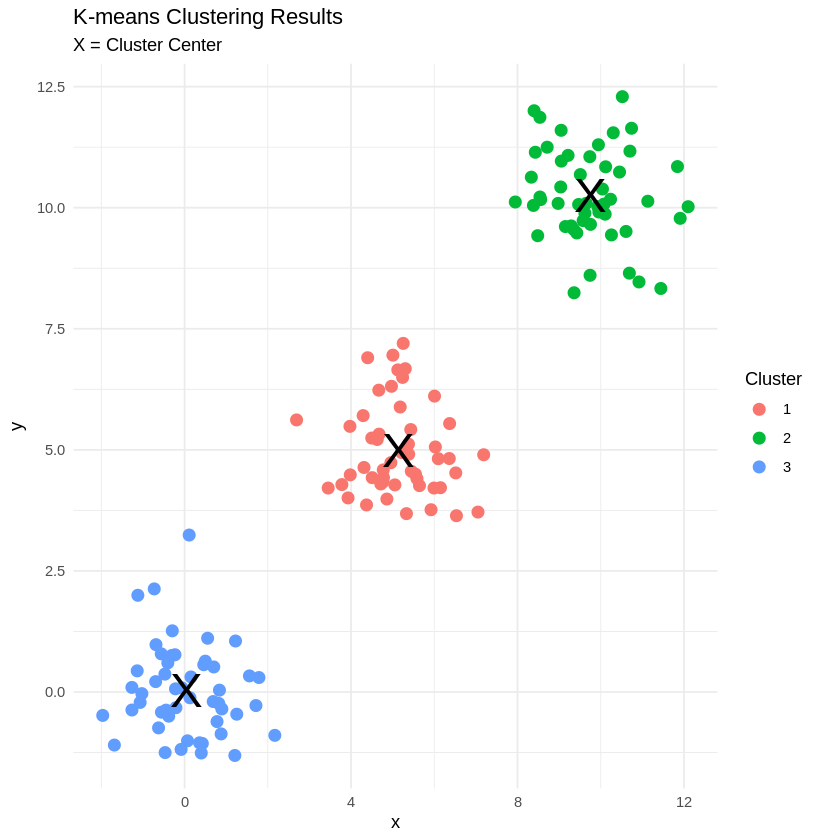

  cluster size ave.sil.width
1       1   50          0.75
2       2   50          0.76
3       3   50          0.78


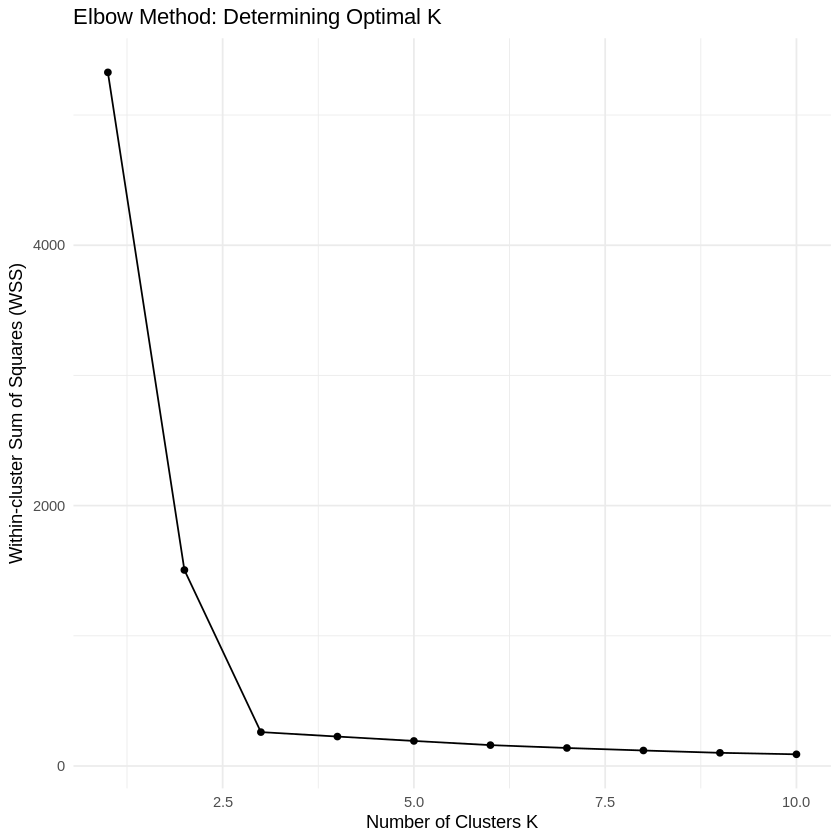

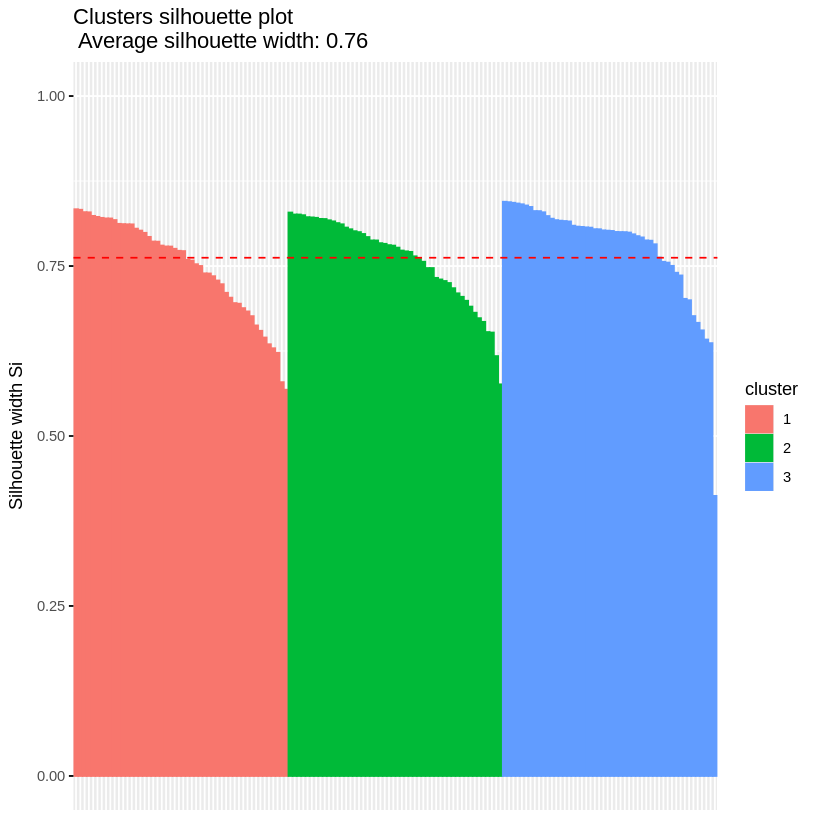

In [ ]:
library(tidyverse)

# Check and try to install missing packages
if (!require("factoextra")) install.packages("factoextra", dependencies = TRUE)
if (!require("cluster")) install.packages("cluster", dependencies = TRUE)

library(factoextra)
library(cluster)

set.seed(123)

# Create data
data <- data.frame(
  x = c(rnorm(50, 0, 1), rnorm(50, 5, 1), rnorm(50, 10, 1)),
  y = c(rnorm(50, 0, 1), rnorm(50, 5, 1), rnorm(50, 10, 1))
)

# 1. Execute K-means
kmeans_result <- kmeans(data, centers = 3, nstart = 25)

# 2. View results
print("=== Cluster Centers ===")
print(kmeans_result$centers)

# 3. Visualization
data$cluster <- kmeans_result$cluster

ggplot(data, aes(x = x, y = y, color = factor(cluster))) +
  geom_point(size = 3) +
  geom_point(data = as.data.frame(kmeans_result$centers),
             aes(x = x, y = y),
             color = "black", size = 10, shape = "X") +
  labs(title = "K-means Clustering Results",
       subtitle = "X = Cluster Center",
       color = "Cluster") +
  theme_minimal()

# 4. Determine optimal K value (Elbow Method)
wss <- sapply(1:10, function(k) {
  kmeans(data, centers = k, nstart = 25)$tot.withinss
})

elbow_data <- tibble(k = 1:10, wss = wss)

ggplot(elbow_data, aes(x = k, y = wss)) +
  geom_line() +
  geom_point() +
  labs(title = "Elbow Method: Determining Optimal K",
       x = "Number of Clusters K",
       y = "Within-cluster Sum of Squares (WSS)") +
  theme_minimal()

# 5. Silhouette Coefficient
sil <- silhouette(kmeans_result$cluster, dist(data))
fviz_silhouette(sil)

### 集群分析步驟
1.   資料預處理
2.   分群前要標準化
3.   K-means
4.   群體描述
5.   營運策略



In [10]:
# 簡易範例
library(tidyverse)

game_log <- tribble(
  ~User_Id, ~Day, ~Min_Aft, ~Min_Eve, ~Min_Mid, ~Buy_Coin, ~Buy_Dia,
  "U1", 1, 80, 20, 10, 0, 0,
  "U1", 2, 70, 25,  5, 0, 0,

  "U2", 1, 75, 30,  8, 0, 0,
  "U2", 2, 65, 35, 12, 0, 0,

  "U3", 1, 15, 90, 12, 3, 0,
  "U3", 2, 20, 85, 15, 4, 0,

  "U4", 1, 10, 80, 20, 4, 0,
  "U4", 2, 15, 95, 15, 3, 0,

  "U5", 1, 10, 20, 100, 0, 5,
  "U5", 2,  5, 15, 110, 0, 4,

  "U6", 1, 15, 25, 95, 0, 4,
  "U6", 2, 10, 20, 105, 0, 5
)

game_log

User_Id,Day,Min_Aft,Min_Eve,Min_Mid,Buy_Coin,Buy_Dia
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
U1,1,80,20,10,0,0
U1,2,70,25,5,0,0
U2,1,75,30,8,0,0
U2,2,65,35,12,0,0
U3,1,15,90,12,3,0
U3,2,20,85,15,4,0
U4,1,10,80,20,4,0
U4,2,15,95,15,3,0
U5,1,10,20,100,0,5


In [11]:
# 行為特徵
behavior <- game_log %>%
  group_by(User_Id) %>%
  summarise(
    Min_Aft = mean(Min_Aft),
    Min_Eve = mean(Min_Eve),
    Min_Mid = mean(Min_Mid),
    Buy_Coin = mean(Buy_Coin),
    Buy_Dia = mean(Buy_Dia),
    .groups = "drop"
  )

behavior

User_Id,Min_Aft,Min_Eve,Min_Mid,Buy_Coin,Buy_Dia
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
U1,75.0,22.5,7.5,0.0,0.0
U2,70.0,32.5,10.0,0.0,0.0
U3,17.5,87.5,13.5,3.5,0.0
U4,12.5,87.5,17.5,3.5,0.0
U5,7.5,17.5,105.0,0.0,4.5
U6,12.5,22.5,100.0,0.0,4.5


In [13]:
# 標準化：讓變數公平比較
min_max <- function(x) {
  if (max(x, na.rm = TRUE) == min(x, na.rm = TRUE)) {
    return(rep(0, length(x)))
  }

  (x - min(x, na.rm = TRUE)) /
    (max(x, na.rm = TRUE) - min(x, na.rm = TRUE))
}

behavior_scaled <- behavior %>%
  mutate(
    across(
      -User_Id,
      min_max
    )
  )

behavior_scaled

# 目的：給K-means使用
cluster_features <- behavior_scaled %>%
  select(-User_Id)

cluster_features

User_Id,Min_Aft,Min_Eve,Min_Mid,Buy_Coin,Buy_Dia
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
U1,1.00000000,0.07142857,0.00000000,0,0
U2,0.92592593,0.21428571,0.02564103,0,0
U3,0.14814815,1.00000000,0.06153846,1,0
U4,0.07407407,1.00000000,0.10256410,1,0
U5,0.00000000,0.00000000,1.00000000,0,1
U6,0.07407407,0.07142857,0.94871795,0,1


Min_Aft,Min_Eve,Min_Mid,Buy_Coin,Buy_Dia
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1.00000000,0.07142857,0.00000000,0,0
0.92592593,0.21428571,0.02564103,0,0
0.14814815,1.00000000,0.06153846,1,0
0.07407407,1.00000000,0.10256410,1,0
0.00000000,0.00000000,1.00000000,0,1
0.07407407,0.07142857,0.94871795,0,1


In [15]:
# K-means分群
set.seed(500)

kmeans_model <- kmeans(
  cluster_features,
  centers = 3,
  nstart = 25  # nstart=25：模型會用25組不同的初始中心點嘗試分群，最後選擇結果較好的版本
)

cluster_result <- behavior %>%
  mutate(
    Cluster = factor(kmeans_model$cluster)
  )

cluster_result

cluster_result_scaled <- behavior_scaled %>%
  mutate(
    Cluster = factor(kmeans_model$cluster)
  )

User_Id,Min_Aft,Min_Eve,Min_Mid,Buy_Coin,Buy_Dia,Cluster
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
U1,75.0,22.5,7.5,0.0,0.0,3
U2,70.0,32.5,10.0,0.0,0.0,3
U3,17.5,87.5,13.5,3.5,0.0,1
U4,12.5,87.5,17.5,3.5,0.0,1
U5,7.5,17.5,105.0,0.0,4.5,2
U6,12.5,22.5,100.0,0.0,4.5,2


In [18]:
# 群體描述
# 先看每一群有多少玩家
cluster_result %>%
  count(Cluster)

# 比較每群的平均行為(使用的是原始數值，因為在商業解讀時，原始分鐘數與購買次數比較有意義)
cluster_profile <- cluster_result %>%
  group_by(Cluster) %>%
  summarise(
    Players = n(),
    Avg_Aft = mean(Min_Aft),
    Avg_Eve = mean(Min_Eve),
    Avg_Mid = mean(Min_Mid),
    Avg_Coin = mean(Buy_Coin),
    Avg_Dia = mean(Buy_Dia),
    .groups = "drop"
  )

cluster_profile

# 依據cluster_profile實際輸出的結果，替群組重新命名
cluster_result <- cluster_result %>%
  mutate(
    Cluster_Name = case_when(
      Cluster == "1" ~ "下午低付費玩家",
      Cluster == "2" ~ "晚間金幣玩家",
      Cluster == "3" ~ "半夜鑽石玩家"
    )
  )

Cluster,n
<fct>,<int>
1,2
2,2
3,2


Cluster,Players,Avg_Aft,Avg_Eve,Avg_Mid,Avg_Coin,Avg_Dia
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2,15.0,87.5,15.50,3.5,0.0
2,2,10.0,20.0,102.50,0.0,4.5
3,2,72.5,27.5,8.75,0.0,0.0


結論：
| 群體特徵        | 行為模式          | 可能的玩家類型    |
| ----------- | ------------- | ---------- |
| 下午遊玩高、購買低   | 下午上線時間長，但不太消費 | 下午低付費／新手玩家 |
| 晚上遊玩高、金幣購買高 | 晚間活躍，且有金幣購買習慣 | 晚間金幣玩家     |
| 半夜遊玩高、鑽石購買高 | 半夜上線，且偏好購買鑽石  | 半夜鑽石玩家     |

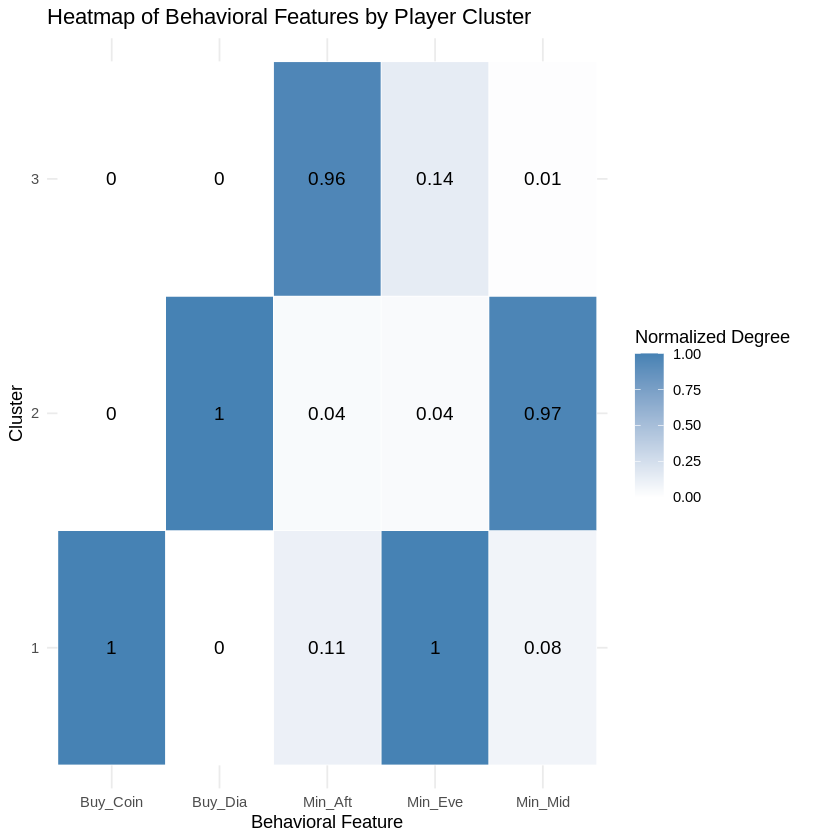

In [23]:
# 繪圖一：群體特徵熱圖->適合快速比較各群的主要特徵
profile_heatmap <- cluster_result_scaled %>%
  group_by(Cluster) %>%
  summarise(
    across(
      c(Min_Aft, Min_Eve, Min_Mid, Buy_Coin, Buy_Dia),
      mean
    ),
    .groups = "drop"
  ) %>%
  pivot_longer(
    cols = -Cluster,
    names_to = "Feature",
    values_to = "Normalized_Value"
  )

ggplot(
  profile_heatmap,
  aes(
    x = Feature,
    y = Cluster,
    fill = Normalized_Value
  )
) +
  geom_tile(color = "white") +
  geom_text(
    aes(label = round(Normalized_Value, 2)),
    color = "black",
    size = 4
  ) +
  scale_fill_gradient(
    low = "white",
    high = "steelblue"
  ) +
  labs(
    title = "Heatmap of Behavioral Features by Player Cluster",
    x = "Behavioral Feature",
    y = "Cluster",
    fill = "Normalized Degree"
  ) +
  theme_minimal()

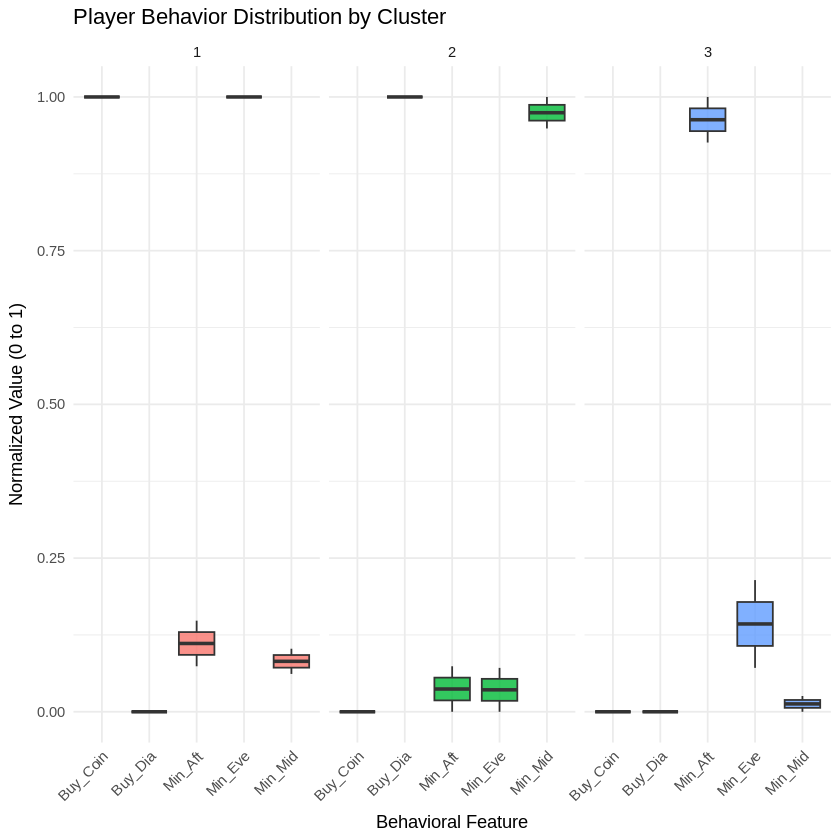

In [22]:
# Boxplot 比較群內分布->看同一群的玩家是否很相似、是否有極端玩家
plot_data <- cluster_result_scaled %>%
  pivot_longer(
    cols = -c(User_Id, Cluster),
    names_to = "Feature",
    values_to = "Normalized_Value"
  )

ggplot(
  plot_data,
  aes(
    x = Feature,
    y = Normalized_Value,
    fill = Cluster
  )
) +
  geom_boxplot(
    show.legend = FALSE,
    alpha = 0.8
  ) +
  facet_wrap(~ Cluster) +
  labs(
    title = "Player Behavior Distribution by Cluster",
    x = "Behavioral Feature",
    y = "Normalized Value (0 to 1)"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(
      angle = 45,
      hjust = 1
    )
  )

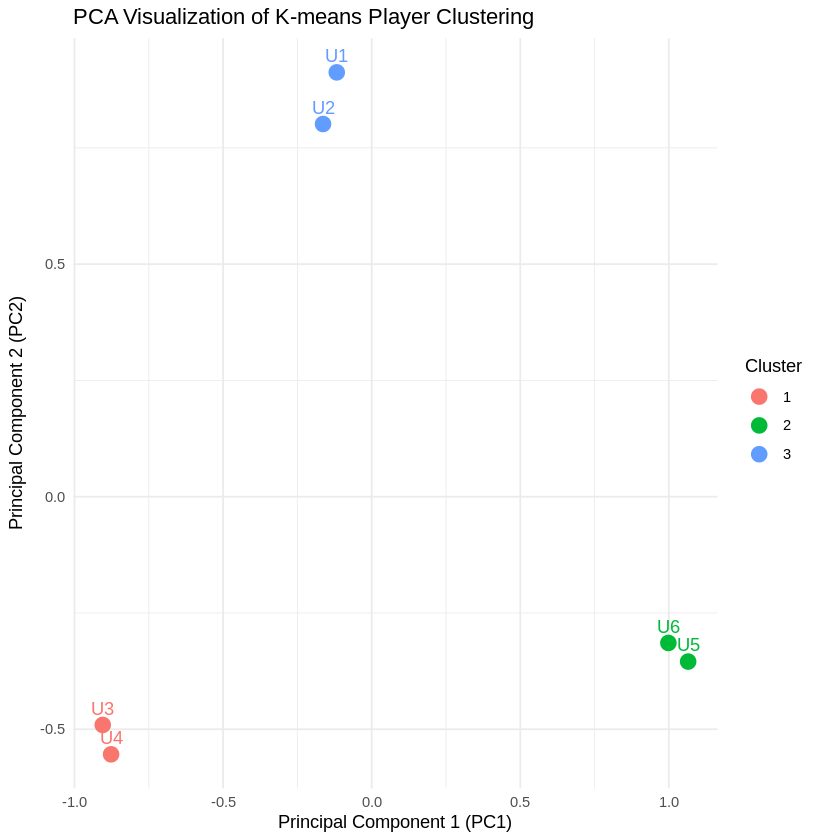

In [24]:
# PCA分群視覺化->將5維資料壓縮成2維，大致觀察不同群是否分開
pca_model <- prcomp(
  cluster_features,
  center = TRUE,
  scale. = FALSE
)

pca_data <- as.data.frame(pca_model$x[, 1:2]) %>%
  mutate(
    User_Id = behavior$User_Id,
    Cluster = factor(kmeans_model$cluster)
  )

ggplot(
  pca_data,
  aes(
    x = PC1,
    y = PC2,
    color = Cluster,
    label = User_Id
  )
) +
  geom_point(size = 4) +
  geom_text(
    vjust = -0.8,
    show.legend = FALSE
  ) +
  labs(
    title = "PCA Visualization of K-means Player Clustering",
    x = "Principal Component 1 (PC1)",
    y = "Principal Component 2 (PC2)",
    color = "Cluster"
  ) +
  theme_minimal()

PCA分群視覺化解讀重點：
*  同色點靠近：代表該群玩家行為較相似。
*  不同顏色群體分得開：代表分群效果相對清楚。
*  不同群大量重疊：可能表示目前的特徵無法清楚區分玩家，或
K 值不適合。
*  個別點離群很遠：可能是特殊玩家，例如超高消費者，值得單獨研究

營運策略：
| 玩家群體    | 行為特徵            | 可採取的策略                         |
| ------- | --------------- | ------------------------------ |
| 下午低付費玩家 | 下午活躍，但購買金幣、鑽石都低 | 下午限定優惠、新手首儲禮包、低價入門商品、完成任務送小額獎勵 |
| 晚間金幣玩家  | 晚上上線時間長，偏好購買金幣  | 晚間金幣加碼、金幣禮包、晚間推播、限時資源活動        |
| 半夜鑽石玩家  | 半夜活躍，鑽石購買較高     | 深夜限定鑽石包、VIP 優惠、稀有道具活動、鑽石與抽卡組合包 |